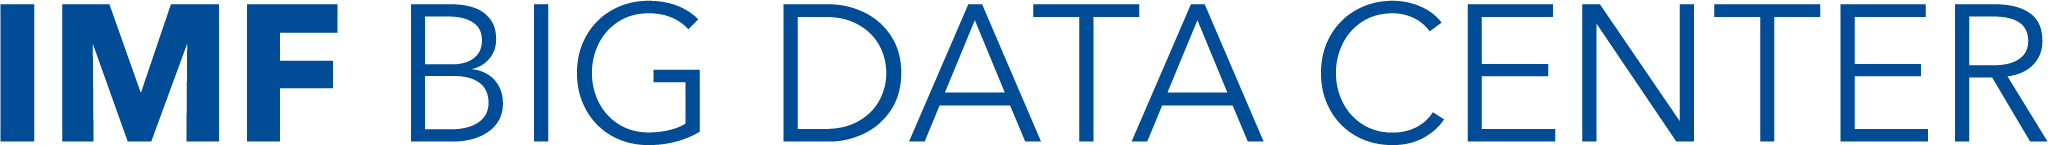

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AlessandraSozzi/BDC_STI_26/blob/main/notebooks/BDC_Challenge_Buildings_Analysis.ipynb)

# Big Data Challenge: Estimating Property Value and Potential Tax Revenue

---

<br>**Contributors:**
<br> **Last update:**
<br> **Description:** This notebook is a group challenge to estimate property values and potential tax revenue from Overture Maps building footprints, using H3 spatial indexing to aggregate buildings and derive summary indicators for a selected city
<br> **References:**

## Setup

Opensource building data sources

1. [Google Open buildings](https://sites.research.google/gr/open-buildings/). The dataset contains 1.8 billion building detection.Cover 58M km2 covering Africa, South Asia, South-East Asia, Latin America and the Caribbean.Dataset include polygon, a confidence score, centriod of the building.[Google Open Buildings 2.5D Temporal Dataset](https://sites.research.google/gr/open-buildings/temporal)

2. [Microsoft building footpring](https://planetarycomputer.microsoft.com/dataset/ms-buildings). Bing Maps is releasing open building footprints around the world. We have detected over 999 million buildings from Bing Maps imagery between 2014 and 2021 including Maxar and Airbus imagery. The data is freely available for download and use under ODbL. Example notebooks are available here: <https://planetarycomputer.microsoft.com/dataset/ms-buildings#Example-Notebook>

3. [Open Street Map](https://osmbuildings.org/). 2.2 billion buildings. Updates monthly with crowdsourced inputs

4. [Overture Maps Foundation (OMF)](https://overturemaps.org/).

---
**For this session we use OMF building data**. OMF includes building data from all sources including Google, Microsoft, Openstreet Map, and Esri Community. For more details, please visit the website. https://overturemaps.org/

### Mount drive

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


### Set the path

In [ ]:
# Set the main path for the workshop files

import os

ROOT = "/content/drive/MyDrive/STI 2026" # Fix based on your own path
workshop_path = os.path.join(ROOT, "Day 4-5 - Capstone Project")
data_path = os.path.join(workshop_path, "buildings-data")

# Check if working
print("Worshop path found: ", os.path.exists(workshop_path))
print("Data path found: ", os.path.exists(data_path))


### Install and import libraries

In [ ]:
%%capture
!pip install h3 # hexagonal-shaped boundaries for efficient manipulation
!pip install overturemaps
!pip install mapclassify

In [ ]:
import shapely
import h3
import overturemaps
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

### Select country and region

[GADM](https://gadm.org/) provides maps and spatial data for all countries and their sub-divisions. You can browse our maps or download the data to make your own maps.


In [ ]:

country_name = "Spain"
country_iso3 = "ESP"
region_name = "Madrid"

# 0 to 4: 0 = country boundary; 4 = municipalities.
# NB: not all countries have 4 levels of administrative geographies
# Check https://geodata.ucdavis.edu/gadm/gadm4.1/json/
geo_level = 4

# Extract all municipalities (level 4 geographies) for the given country
boundary_url = f'https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_{country_iso3}_{geo_level}.json'

# Fetch GeoJSON data from the URL
municipalities = gpd.read_file(boundary_url)

# How many municipalities are there in Spain?
municipalities.shape[0]

In [ ]:
municipalities.head()

## Data exploration

Explore level 4 boundaries

In [ ]:
# print all fields for first record
municipalities.iloc[0]

In [ ]:
# Show location on interactive map
municipalities.iloc[[0]].explore()

Extract ALL municipalities for the Region of Madrid

In [ ]:
# Filter for the give Region
subset_municipalities = municipalities[municipalities['NAME_2'] == region_name]

print(f"Found {subset_municipalities.shape[0]} municipalities for {region_name}.")

In [ ]:
# Visualize the boundaries
subset_municipalities.explore()

In [ ]:
print(f"Municipalities in the Region {region_name}:")
print()

print(subset_municipalities['NAME_4'].unique())

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot All municipalities whithin the Region of Madrid
subset_municipalities.plot(ax=ax,
                           legend=True,
                           legend_kwds={"loc": "center left"})

# Highlight Madrid city in green
madrid_center = subset_municipalities[subset_municipalities['NAME_4'] == 'Madrid']
madrid_center.plot(ax=ax, color='green')

# Set title
plt.title(f'Municipalities of {region_name}')
plt.show()

## Buildings

We retrieve buildings only for the main city area of Madrid.

In [ ]:
# Select 1 municipality
municipality_name = "Madrid"
madrid = subset_municipalities[subset_municipalities['NAME_4'] == municipality_name]
madrid

In [ ]:
madrid.explore()

In [ ]:
# Exatract the geometry polygon and define our AOI (area of interest)
aoi_shape = shapely.geometry.shape(madrid.iloc[0].geometry)
aoi_shape

In [ ]:
# Define the AOI Bounding Box. We need this to extract the building footprints
bbox = aoi_shape.bounds
bbox

### Download buildings for the municipality of Madrid

In [ ]:
# Use the record_batch_reader method to pull the data into a PyArrow table.
# Specify we want to grab buildings data.
# Explore the other options available here: https://docs.overturemaps.org/guides/
table = overturemaps.record_batch_reader("building", bbox).read_all()
table = table.combine_chunks()

In [ ]:
# convert to dataframe
overture_df = table.to_pandas()

# DataFrame to GeoDataFrame, set crs
buildings_gdf = gpd.GeoDataFrame(
    overture_df,
    geometry=overture_df['geometry'].apply(shapely.wkb.loads),
    crs="EPSG:4326"
)

# Keep only the building the falls whithin the AOI (ie city of Madrid)
buildings_gdf = buildings_gdf[buildings_gdf.within(aoi_shape)]

print(f"Found a total of {buildings_gdf.shape[0]} buildings")

buildings_gdf.head()

### Plot a smaller area in the city

In [ ]:
# Let's define a smaller area around Madrid city center.
# You can use this tool to define a bounding box https://boundingbox.klokantech.com/ and get the GeoJSON coordinates
# Tip prompt: Ask Gemini: give me xmin, xmax, ymin, ymax from this bounding box

xmin = -3.7136578719
xmax = -3.6919974333
ymin = 40.4134655971
ymax = 40.4235567914

# Plot the building footprints filtered within the bounding box
buildings_gdf.cx[xmin:xmax, ymin:ymax].plot(figsize=(10, 10),
                  edgecolor="black",
                  facecolor="lightblue")

# # Show the plot
plt.title("Overture Building Footprints  - " + municipality_name + " City Center")
plt.show()

### Building Properties

| Property | Type | Description |
|---|---|---|
| `id` | string | Stable Overture feature identifier (128-bit string). |
| `version` | integer | Incremented when the feature changes. |
| `names` | object | Optional multilingual names; includes `primary`, `common` (by lang), and `rules` (variants). |
| `level` | integer | Vertical level for stacking/ordering (usually `1` for footprints). |
| `subtype` | enum(string) | Broad building purpose (e.g., `residential`, `commercial`, `industrial`, `education`, `medical`, `religious`, `transportation`, etc.). |
| `class` | enum(string) | Finer category (e.g., `house`, `apartments`, `office`, `warehouse`, `school`, `hospital`, `parking`, `temple`, …). |
| `has_parts` | boolean | `true` if the building has related `building_part` features. |
| `height` | number | Overall building height (SI units; meters). |
| `num_floors` | integer | Count of above-ground floors. |
| `num_floors_underground` | integer | Count of below-ground floors. |
| `is_underground` | boolean | `true` if the structure is underground. |
| `roof_height` | number | Height of roof structure (if available). |
| `roof_shape` | enum(string) | Roof form (e.g., `flat`, `gabled`, `hipped`, …). |
| `roof_material` | enum(string) | Roof material (e.g., `metal`, `tile`, `concrete`, …). |
| `facade_material` | enum(string) | Exterior wall material (e.g., `brick`, `stone`, `wood`, …). |
| `sources` | array(object) | Provenance per property; each item has `dataset`, `property` (JSON-pointer to the field), and `confidence` (0–1). |
| `ext_*` | any | Customer/user extensions (namespaced as `ext_…`). |

> **Notes**
> - Many attributes (subtype/class/materials) are harmonized from **OSM tags** and other providers into fixed enumerations defined by the schema.  
> - Measurements follow **SI units** and are provided as scalars **without unit strings**.  
> - If a building has internal segmentation (e.g., wings/sections), those appear as separate features under **`building_part`** with similar shape/height properties.

**Docs:** See the official [schema pages](https://docs.overturemaps.org/schema/concepts/by-theme/buildings/) for full enums and examples

In [ ]:
record_id = 100

# print all fields for first record
print(buildings_gdf.iloc[record_id])

# Show location on interactive map
buildings_gdf.iloc[[record_id]].explore()

### Summary Statistics

##### ❓ **How many buildings are in the Municipality of Madrid**



In [ ]:
num_buildings = buildings_gdf.shape[0]
print(f"Number of buildings: {num_buildings}")

##### ❓ **How many buildings are residential**

In [ ]:
num_res_buildings = buildings_gdf[buildings_gdf.subtype=="residential"].shape[0]
print(f"Number of Residential buildings: {num_res_buildings}")

##### ❓ **What is the distribution by subtype**


In [ ]:
buildings_gdf.subtype.value_counts().plot(
    kind="bar",
    title="Number of Buildings by Subtype",
    xlabel="Subtype",
    ylabel="Count")

##### ❓ **What is the total area covered by the buildings**

In [ ]:
# Reproject to a suitable projected CRS for accurate area calculation (e.g., ETRS89 / UTM zone 30N for Spain)
buildings_gdf_projected = buildings_gdf.to_crs(epsg=25830)

total_area = buildings_gdf_projected.geometry.area.sum()
print(f"Total area (sq meters): {total_area:.2f}")

avg_area = buildings_gdf_projected.geometry.area.mean()
print(f"Average area (sq meters): {avg_area:.2f}")

max_area = buildings_gdf_projected.geometry.area.max()
print(f"Maximum area (sq meters): {max_area:.2f}")

##### ❓ **Can you think of other information to extract from the data 🤓**

## H3 binning

## 🧩 **H3 Spatial Indexing**

**H3** is a hierarchical, hexagon-based **spatial indexing system** developed by Uber for efficiently representing and analyzing geospatial data. It divides the Earth’s surface into a continuous grid of **hexagonal cells** (and a few pentagons) at multiple resolutions, from coarse (global) to fine (sub-meter). Each hexagon is assigned a unique **H3 index**, allowing complex spatial operations—such as aggregation, proximity analysis, and spatial joins—to be performed quickly and at scale.  

Unlike square grids, hexagons minimize edge effects and provide more uniform adjacency, making H3 particularly useful for **big geospatial data**, **mobility analytics**, **raster-to-vector transformations**, and **spatial downscaling or upscaling**. The indexing hierarchy (resolutions 0–15) supports seamless zooming and consistent spatial partitioning across datasets.

> **Reference:** [H3: Uber’s Hexagonal Hierarchical Spatial Index](https://h3geo.org/)

#### Find H3 hexagon index based on the centroid of each building

In [ ]:
h3_level = 10 # ≈ 13.6 km²
h3_column_name = f'h3_level_{h3_level}'

# Convert lat/long centroids of each building footprint into the coresponding h3 cell ID
def lat_lng_to_h3(row):
    return h3.latlng_to_cell(
      row.geometry.centroid.y, row.geometry.centroid.x, h3_level)

In [ ]:
# Add a new column with the H3 index corresponding to the centroid of each building footprint
buildings_gdf[h3_column_name] = buildings_gdf.apply(lat_lng_to_h3, axis=1)

# One extra column has now been added
buildings_gdf.head()

#### Now we can compute how many buildings fall into the each hexagon

In [ ]:
n_buildings_by_h3 = (buildings_gdf
                     .groupby(h3_column_name) # aggregate by h3 id
                     .size() # count how many
                     .reset_index(name='count'))
n_buildings_by_h3.head()

### Add the shape of the hexagons

In [ ]:
# Add geometry of the hexbins
n_buildings_by_h3['geometry'] = n_buildings_by_h3[h3_column_name].apply(lambda x: h3.cells_to_geo([x]))
n_buildings_by_h3['geometry'] = n_buildings_by_h3['geometry'].apply(shapely.geometry.shape)

# Convert into geopandas dataframe
all_buildings_by_h3_geo = gpd.GeoDataFrame(
    n_buildings_by_h3,
    geometry='geometry',
    crs=4326
)

all_buildings_by_h3_geo.head()

### Visualize H3 hexagons on a interactive map and use the 'count' of buildings per hexagon to set the color intensity

In [ ]:
all_buildings_by_h3_geo.explore(column='count')

##### ❓ **Can you spot any hexagon with unusual number of buildings 🤓**

##### ❓ **Can you tell why 🤓**

### Summary indicators

##### ❓ **What is the average number of buildings per hexagon**

In [ ]:
avg_count = all_buildings_by_h3_geo['count'].mean()
print(f"Average number of buildings per Hexagon: {avg_count:.2f}")

max_count = all_buildings_by_h3_geo['count'].max()
print(f"Maximum number of buildings per Hexagon: {max_count:.2f}")

min_count = all_buildings_by_h3_geo['count'].min()
print(f"Minimum number of buildings per Hexagon: {min_count:.2f}")

## Filter and process data

### Residential buildings only

In [ ]:
residential_buildings_gdf = buildings_gdf[buildings_gdf['subtype'] == 'residential'].copy()
residential_buildings_gdf.head()

In [ ]:
# Plot the same area we used before but now only displaying residential buildings
xmin = -3.7136578719
xmax = -3.6919974333
ymin = 40.4134655971
ymax = 40.4235567914

# Plot the building footprints filtered within the bounding box
residential_buildings_gdf.cx[xmin:xmax, ymin:ymax].plot(figsize=(10, 10),
                  edgecolor="black",
                  facecolor="lightblue")

# Show the plot
plt.title("Overture Residential Building Footprints  - " + municipality_name + " City Center")
plt.show()

##### ❓ **Do you see any difference with the earlier map**

### Calculate property values

Before we calculate total area, property value and tax, we need to handle potential missing values.

There are various methods to impute missing values, including machine learning. For now use, we just use the median floor to impute missing floor data for some areas.

In [ ]:
median_floors_imp = residential_buildings_gdf['num_floors'].median()
print(f"Median number of floors: {median_floors_imp:.2f}")

In [ ]:
# Use the median_floors_imp to fill in the missing values
residential_buildings_gdf.fillna({'num_floors': median_floors_imp},
                                 inplace=True)

In [ ]:
# verify there is no missing data anymore
residential_buildings_gdf['num_floors'].isnull().sum()

To calculate average property taxes from real estate, we need to get data on average prices per square meter. Data are typically available from online real estate companies. For that sake of simplicity, assume that price per square meter in 2025 is uniform in Madrid (1730 €/m²), regardless of property type, number of floors, etc. And property value is only assessed from actual building area ignoring other amenities such as back yard, swimming pools, etc. Advanced analysis, could add these attributes and other local tax codes.

In [ ]:
# Total square meters = median_floors_imp*total_area
# Estimated value = Total square meters*1730. Source: average price per square meter from: https://rpubs.com/l_tresya/1002515 and data from: https://www.kaggle.com/datasets/mirbektoktogaraev/madrid-real-estate-market
# Estimated tax = Estimated value(Cadastral Value) x 0.428% (source: https://diario.madrid.es/blog/2024/11/13/madrid-sigue-reduciendo-el-ibi-para-compensar-la-nueva-tasa-de-residuos/#:~:text=En%202025%2C%20el%20tipo%20general,d%C3%ADa%20de%20la%20ciudadan%C3%ADa%20madrile%C3%B1a.)

In [ ]:
# Reproject to a suitable projected CRS for accurate area calculation (e.g., ETRS89 / UTM zone 30N for Spain)
residential_buildings_gdf_projected = residential_buildings_gdf.to_crs(epsg=25830)

In [ ]:
# Add a new column with the area (in square meters) for each residential building
residential_buildings_gdf_projected['area_sq_meters'] = residential_buildings_gdf_projected.geometry.area

In [ ]:
# Calculate Total Square Meters = Sum of (area * num_floors) for residential buildings
total_estimated_square_meters = (residential_buildings_gdf_projected['area_sq_meters'] * residential_buildings_gdf_projected['num_floors']).sum()

In [ ]:
# Estimated value = Total square meters * 1730 €/m²
price_per_square_meter = 1730
estimated_value = total_estimated_square_meters * price_per_square_meter

In [ ]:
# Estimated tax = Estimated value (Cadastral Value) * 0.428%
tax_rate = 0.00428 # 0.428%
estimated_tax = estimated_value * tax_rate

In [ ]:
print(f"Total Estimated Square Meters (Residential): {total_estimated_square_meters:.2f}")
print(f"Estimated Total Property Value (Residential): {estimated_value:.2f}")
print(f"Estimated Total Property Tax Revenue (Residential): {estimated_tax:.2f}")

##### ❓ **What other dataset could you use 🤓**
Sales tax? addresses of business? Orbis type data?

##### ❓ **Can you think of better methods to estimate missing values 🤓**


##### ❓ **Can you think of a better methodology if you had additional data available 🤓**
